In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

/kaggle/input/datasets/ashfiyag/online-retail-ii-xlsx/online_retail_II.xlsx
Libraries imported successfully!


In [32]:
df = pd.read_excel(
    "/kaggle/input/online-retail-ii/online_retail_II.xlsx"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/online-retail-ii/online_retail_II.xlsx'

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", file)

In [ ]:
df = pd.read_excel(
    "/kaggle/input/datasets/ashfiyag/online-retail-ii-xlsx/online_retail_II.xlsx"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

In [ ]:
# Dataset structure
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

In [ ]:
# Make a copy before cleaning
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows without Customer ID
df_clean = df_clean.dropna(subset=["Customer ID"])

# Remove rows without Description
df_clean = df_clean.dropna(subset=["Description"])

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate rows after cleaning:", df_clean.duplicated().sum())

In [ ]:
# Check Quantity and Price

print("Quantity statistics:")
print(df_clean["Quantity"].describe())

print("\nPrice statistics:")
print(df_clean["Price"].describe())

print("\nTransactions with Quantity <= 0:",
      (df_clean["Quantity"] <= 0).sum())

print("Transactions with Price <= 0:",
      (df_clean["Price"] <= 0).sum())

In [ ]:
# Keep only valid purchase transactions

df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

print("Dataset shape after removing invalid transactions:", df_clean.shape)

print("\nQuantity minimum:", df_clean["Quantity"].min())
print("Price minimum:", df_clean["Price"].min())

In [33]:
# Calculate total transaction value

df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["Price"]
)

print("TotalAmount created successfully!")

display(
    df_clean[
        ["Customer ID", "Invoice", "Quantity", "Price", "TotalAmount"]
    ].head()
)

TotalAmount created successfully!


,Customer ID,Invoice,Quantity,Price,TotalAmount
0,13085.0,489434,12,6.95,83.4
1,13085.0,489434,12,6.75,81.0
2,13085.0,489434,12,6.75,81.0
3,13085.0,489434,48,2.10,100.8
4,13085.0,489434,24,1.25,30.0


In [34]:
# Descriptive statistics

display(
    df_clean[
        ["Quantity", "Price", "TotalAmount"]
    ].describe()
)

,Quantity,Price,TotalAmount
count,400916.000000,400916.000000,400916.000000
mean,13.767418,3.305826,21.945330
std,97.638385,35.047719,77.758075
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,5.000000
50%,5.000000,1.950000,12.500000
75%,12.000000,3.750000,19.500000
max,19152.000000,10953.500000,15818.400000


## Descriptive Statistics

Descriptive statistics were calculated for Quantity, Price, and TotalAmount to understand the purchasing behaviour and identify the range and variation in transaction values.

In [35]:
# Set the analysis date as one day after the last transaction
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Last transaction date:", df_clean["InvoiceDate"].max())
print("Analysis date:", analysis_date)

Last transaction date: 2010-12-09 20:01:00
Analysis date: 2010-12-10 20:01:00


In [36]:
# Create customer-level RFM features

rfm = df_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("Number of customers:", len(rfm))
print("RFM shape:", rfm.shape)

display(rfm.head())

Number of customers: 4312
RFM shape: (4312, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [37]:
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


## Customer-Level RFM Analysis

Customer purchasing behaviour was summarized using RFM features:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices associated with the customer.
- **Monetary:** Total amount spent by the customer.

These three behavioural features are used for customer segmentation.

## RFM Feature Standardization

The RFM features have different scales. Standardization is applied so that Recency, Frequency, and Monetary value contribute fairly to the K-Means clustering process.

In [38]:
# Select RFM features
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Standardization completed!")
print("Scaled RFM shape:", rfm_scaled.shape)

Standardization completed!
Scaled RFM shape: (4312, 3)


## Elbow Method

The Elbow Method is used to identify an appropriate number of clusters for K-Means. The within-cluster sum of squares (inertia) is calculated for different values of K.

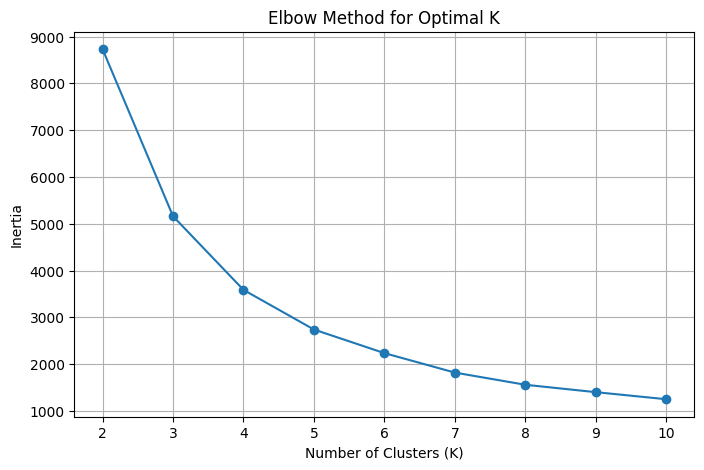

In [39]:
# Calculate inertia for different numbers of clusters

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.grid(True)
plt.show()

## K-Means Customer Segmentation

K-Means clustering is applied to the standardized RFM features to divide customers into distinct behavioural segments.

In [40]:
# Apply K-Means clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")
print("Number of clusters:", optimal_k)

print("\nCustomers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

K-Means clustering completed!
Number of clusters: 4

Customers in each cluster:
Cluster
0    3204
1    1047
2       5
3      56
Name: count, dtype: int64


In [41]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


## Customer Distribution by Cluster

The number of customers in each cluster is visualized to understand the size of each customer segment.

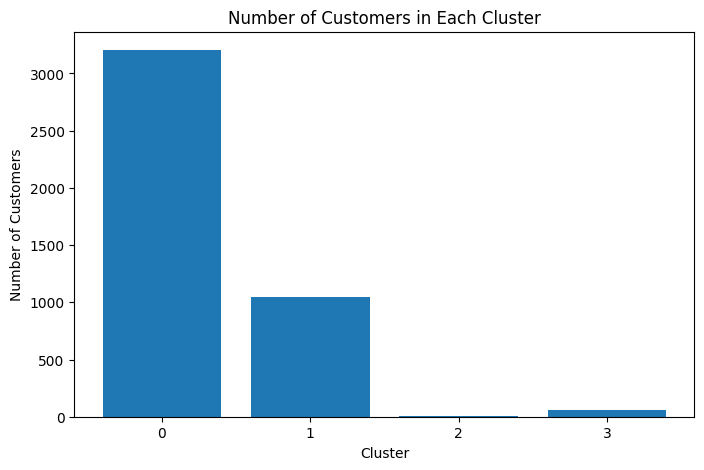

In [42]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.show()

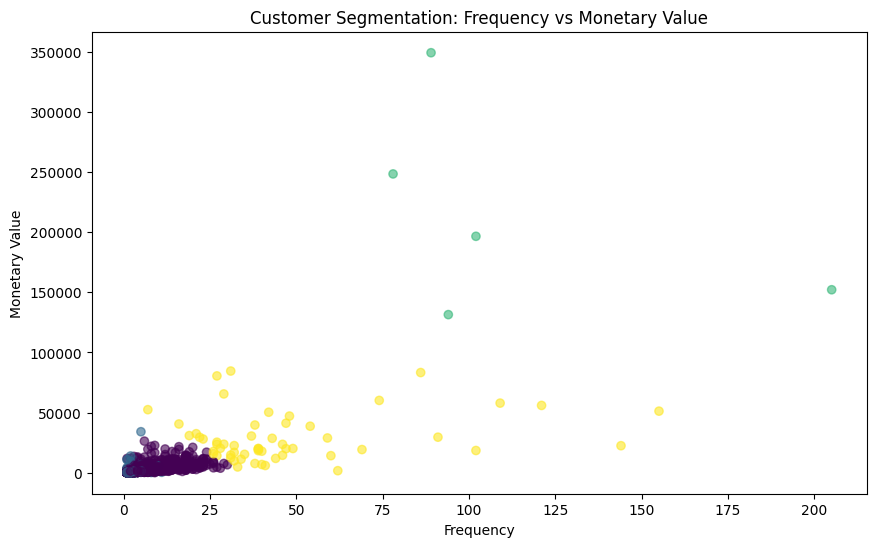

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation: Frequency vs Monetary Value")
plt.show()

In [44]:
# Detailed cluster profile

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42


In [45]:
# Calculate relative cluster performance

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42


In [46]:
# Identify the best and worst clusters based on RFM behaviour

print("Cluster with lowest average Recency:")
print(cluster_profile["Avg_Recency"].idxmin())

print("\nCluster with highest average Frequency:")
print(cluster_profile["Avg_Frequency"].idxmax())

print("\nCluster with highest average Monetary value:")
print(cluster_profile["Avg_Monetary"].idxmax())

Cluster with lowest average Recency:
2

Cluster with highest average Frequency:
2

Cluster with highest average Monetary value:
2


In [47]:
display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42


In [48]:
# Assign meaningful names to the customer segments

segment_names = {
    0: "Regular Customers",
    1: "At-Risk / Low-Value Customers",
    2: "High-Value Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

display(
    rfm[
        ["Customer ID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]
    ].head()
)

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,1,At-Risk / Low-Value Customers
1,12347.0,3,2,1323.32,0,Regular Customers
2,12348.0,74,1,222.16,0,Regular Customers
3,12349.0,43,3,2671.14,0,Regular Customers
4,12351.0,11,1,300.93,0,Regular Customers


In [49]:
# Final customer segment profile

segment_profile = rfm.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(segment_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk / Low-Value Customers,1047,242.98,1.66,593.54
High-Value Customers,5,5.60,113.60,215535.00
Loyal Customers,56,14.91,47.02,28896.42
Regular Customers,3204,43.03,4.46,1710.65


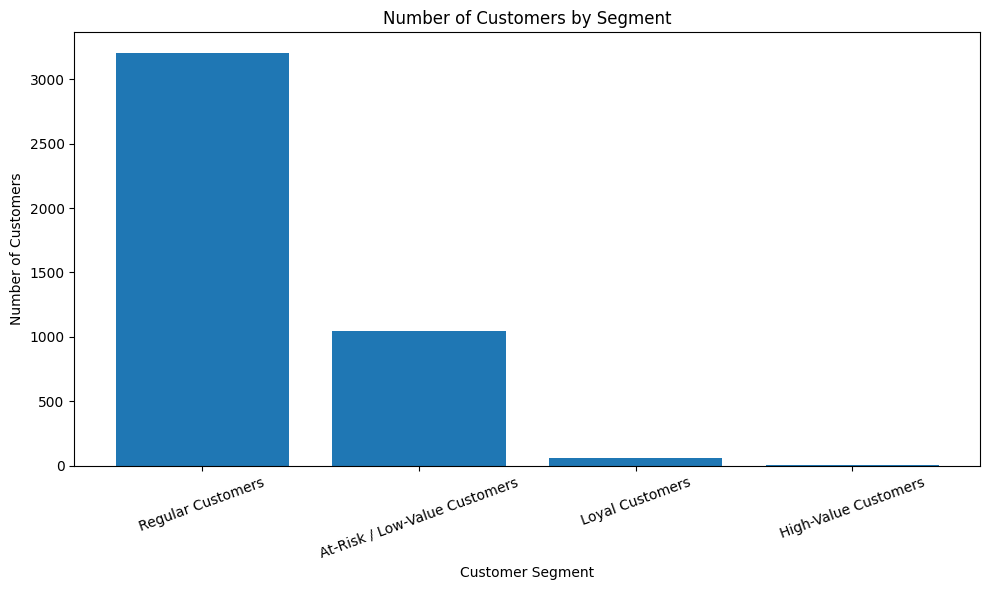

In [50]:
# Customer count by segment

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(segment_counts.index, segment_counts.values)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Segment")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Customer Segmentation Insights

- **High-Value Customers:** These customers have very low recency, very high purchase frequency, and extremely high monetary value. They should receive VIP treatment, exclusive offers, and loyalty rewards.
- **Loyal Customers:** These customers purchase frequently and have relatively recent transactions. Loyalty programs and personalized recommendations can help retain them.
- **Regular Customers:** These customers show moderate purchasing activity and spending. Targeted promotions can encourage them to purchase more frequently.
- **At-Risk / Low-Value Customers:** These customers have high recency, low purchase frequency, and lower spending. Re-engagement campaigns, discounts, and personalized offers can help bring them back.

### Business Recommendations

The company should prioritize retaining High-Value and Loyal Customers while using targeted re-engagement campaigns for At-Risk / Low-Value Customers. Regular Customers can be encouraged to increase their purchase frequency through loyalty programs and personalized promotions.

## RFM Cluster Visualization

The customer segments are visualized using different combinations of RFM features to identify differences in customer purchasing behaviour.

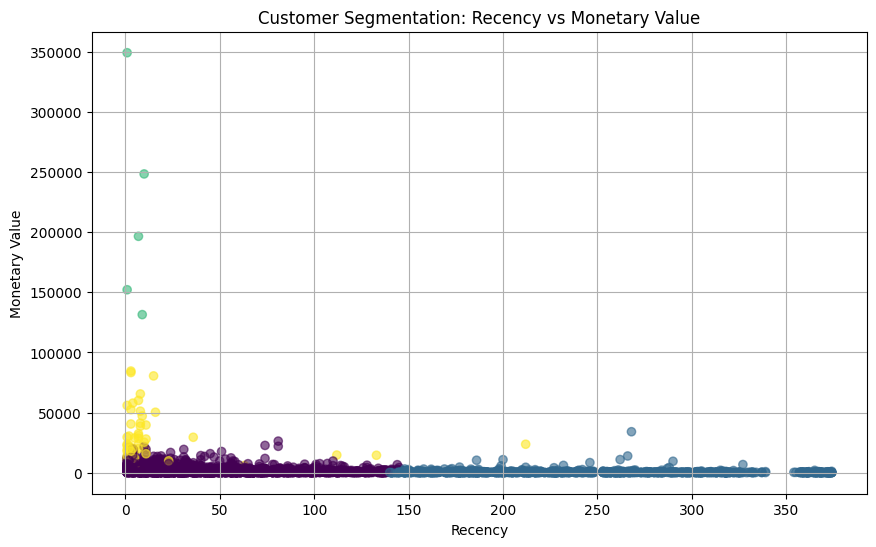

In [51]:
# Visualize clusters using Recency and Monetary value

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation: Recency vs Monetary Value")
plt.grid(True)
plt.show()

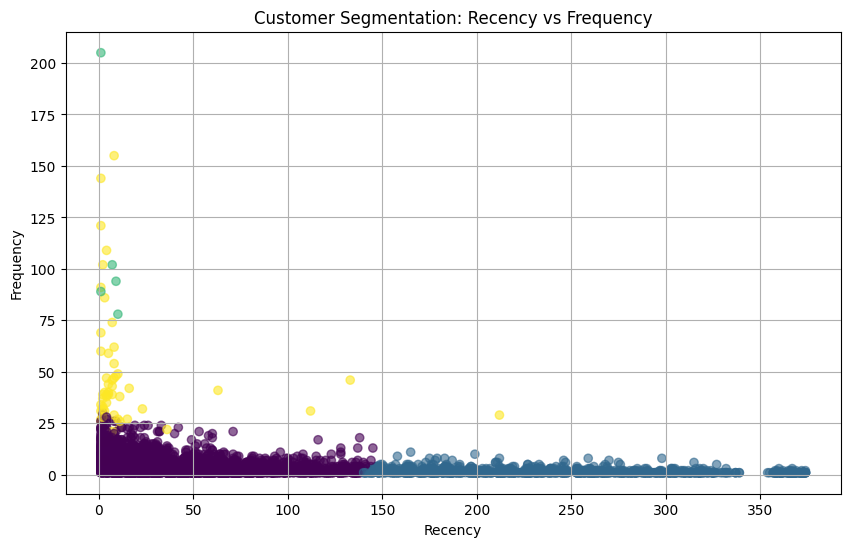

In [52]:
# Visualize clusters using Recency and Frequency

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Customer Segmentation: Recency vs Frequency")
plt.grid(True)
plt.show()

## Visualization Observations

The cluster visualizations show clear differences in customer purchasing behaviour.

Cluster 2 represents High-Value Customers because they have very low recency, very high purchase frequency, and extremely high monetary value.

Cluster 3 represents Loyal Customers with relatively recent purchases, high frequency, and high spending.

Cluster 0 represents Regular Customers with moderate recency, frequency, and monetary value.

Cluster 1 represents At-Risk / Low-Value Customers because they have the highest recency, lowest frequency, and lowest monetary value among the segments.

# Conclusion

This project successfully segmented customers using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering.

Four customer segments were identified based on purchasing behaviour:

- **High-Value Customers:** Cluster 2, with very recent purchases, extremely high purchase frequency, and very high spending.
- **Loyal Customers:** Cluster 3, with recent purchases, high purchase frequency, and high spending.
- **Regular Customers:** Cluster 0, with moderate purchasing activity and spending.
- **At-Risk / Low-Value Customers:** Cluster 1, with less recent purchases, low purchase frequency, and lower spending.

The segmentation can help businesses develop targeted marketing strategies. High-value and loyal customers should be retained through VIP rewards and personalized offers, while at-risk customers can be targeted with re-engagement campaigns and discounts.

Overall, RFM analysis combined with K-Means clustering provides a useful approach for understanding customer behaviour and supporting data-driven marketing decisions.